In [1]:
import argparse
from typing import List
from utils.metrics1 import cacluate_interval_score,evaluate_regress
from utils.tools import converge
from utils.build_metric_summary_df import build_metric_summary_df
from data.data_process import DataLoader
from data.data_process_external import DataLoaderExternal
from models.custom_mlp import CustomMLP
from models.custom_tabpfn import CustomTabPFN
from models.custom_ngbt import CustomNGBoost
from models.custom_tabilc import CustomTabICL
from models.custom_tabm1 import CustomTABM1,TabMConfig
from models.upe3D import UPE3AModel
from pathlib import Path
import numpy as np
import pandas as pd
import gc
import os
from utils.tools import set_seed
import torch
import matplotlib.pyplot as plt

set_seed(3407)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
  
day_set=30    # train day set inclunding(train_valid_test)

zhixin=np.array([0,0.3,0.5,0.7,0.9]) # prediction confidence levelsnfidential 
# the first value must be 0, corresponding to the 0.5 quantile (deterministic point prediction),
# while the remaining confidence levels can be flexibly specified in ascending order,
#  e.g., [0, 0.3, 0.9] or [0, 0.1, 0.2, 0.3, 0.6, 0.9]

# zhixin=[0,0.3,0.5,0.7,0.9]
zhixin1=zhixin[1:]

# data_set_list = ['data_JS', 'data_FBS', 'data_NG', 'data_AU', 'data_GED']
data_set_list = ['data_GED']
# data_set_list = ['data_GED']
# data_set_list = ['data_JS', 'data_NG', 'data_AU', 'data_GED']
# data_set_list = ['data_JS', 'data_NG', 'data_AU']
# Geographic information for different datasets
site_config = {
    'data_FBS': {
        'std_meridian_deg': 120,
        'longitude': 104.0,
        'latitude': 37.0
    },
    'data_JS': {
        'std_meridian_deg': 120,
        'longitude': 93.4,
        'latitude': 36.0
    },
    'data_NG': {
        'std_meridian_deg': 120,
        'longitude': 113.4,
        'latitude': 38.0
    },
    'data_GED': {
        'std_meridian_deg': 0,
        'longitude': 133.87,
        'latitude': -23.7
    },
    'data_AU': {
        'std_meridian_deg': 120,
        'longitude': 130.98,
        'latitude': -25.24
    }
}


# method_choose_list=['TabPFN','TABM','LightGBM','Baye','HGBoost','NGBoost','LSTM','KAN','MLP','UPF3']
method_choose_list=['TabPFN','TABM','NGBoost','TabICL','Baye','LightGBM','HGBoost','MLP','LSTM','KAN','UPF2A','UPF2B','UPF2C','UPF3A','UPF3B','UPF3C']


method_choose_list=['UPF3A']
method_choose_list1=[]

prdict_y_list_all=[]
true_y_list_all=[]
lower_y_list_all=[]
up_y_list_all=[]

output_df_ngboost_all=[]
point_predict_all=[]
interval_predict_all=[]
df_test_list_all=[]

prdict_y_list_external_all = []
true_y_list_external_all = []
lower_y_list_external_all = []
up_y_list_external_all = []
point_predict_external_all = []
interval_predict_external_all = []
df_test_list_external_all=[]
index=np.arange(0,len(method_choose_list))  #method choose
# index=[0,1,2,3,4,5,6]

# index=[0,1,2,3]
# index=[0,1,2,4,10,11,12,13,14]
# index=[17]
for index_set in index:
    method_choose=method_choose_list[index_set]
    method_choose_list1.append(method_choose)
    station_name_list=[] #record the station_name of all eara
    pv_station_data_list=[] #record the data of all station
    point_predict=[]  
    interval_predict=[]  
    true_y_list=[]
    prdict_y_list=[]
    lower_y_list=[]
    up_y_list=[]

    true_y_list_external = []
    prdict_y_list_external = []
    lower_y_list_external = []
    up_y_list_external = []
    point_predict_external = []
    interval_predict_external = []

    model_list=[]
    standard_list=[]
    mae_vaild=0
    station_idx1=0
    for data_test_name in data_set_list:
        project_root = Path.cwd()
        dataset_folder_path = project_root / 'datasets' / data_test_name

        print(dataset_folder_path)
        
        dataset_paths = os.listdir(dataset_folder_path)
        std_meridian_deg = site_config[data_test_name]['std_meridian_deg']
        longitude = site_config[data_test_name]['longitude']
        latitude = site_config[data_test_name]['latitude']


        # for station_idx in range(0,len(dataset_paths)):
        for station_idx in range(1,2):
        # for station_idx in range(0,1):
            fafian_num=station_idx
            station_idx1=station_idx1+1; 

            dataset_path = dataset_paths[station_idx]
            # print(dataset_path) 

            station_name = dataset_path[:-5] 
            # print(station_name) 
            station_name_list.append(station_name)

            # df_all = pd.read_excel(dataset_folder_path + '/' + dataset_path)
            df_all = pd.read_excel(dataset_folder_path / dataset_path)

            df_process=df_all.dropna()

            df_process['row_index'] =np.arange(len(df_process))

            df_augmented = df_process.copy()

            method_choose1=method_choose

            total_main = int(day_set * 96)
            train_end = int(day_set * 0.8 * 96)
            valid_end = int(day_set * 0.9 * 96)
            test_end  = int(day_set * 1.0 * 96)
            ext_end   = int(day_set * 1.1 * 96)

            df_train_list = df_process[(df_process['row_index'] >= 0) & (df_process['row_index'] < train_end)]
            df_vaild_list = df_process[(df_process['row_index'] >= train_end) & (df_process['row_index'] < valid_end)]
            df_test_list = df_process[(df_process['row_index'] >= valid_end) & (df_process['row_index'] < test_end)]
            df_test_list_external = df_process[(df_process['row_index'] >= test_end) & (df_process['row_index'] < ext_end)]
            
            drop_column=['row_index']

            df_train_list1=df_train_list.copy()
            df_train_list1=df_train_list1.drop(drop_column , axis=1)

            df_vaild_list1=df_vaild_list.copy()
            df_vaild_list1=df_vaild_list1.drop(drop_column , axis=1)

            df_test_list1=df_test_list.copy()
            df_test_list1=df_test_list1.drop(drop_column , axis=1)

            df_test_list_external1=df_test_list_external.copy()
            df_test_list_external1=df_test_list_external1.drop(drop_column , axis=1)
            
            dataloader = DataLoader(latitude,longitude,std_meridian_deg,df_train_list1,df_vaild_list1,df_test_list1)

            (train_x, train_y, train_x_nor,train_y_nor,
                    train_aug_x, train_aug_y,train_aug_x_nor,train_aug_y_nor,
                    val_x, val_y,val_x_nor, val_y_nor,
                    val_aug_x, val_aug_y,val_aug_x_nor, val_aug_y_nor,
                    test_x, test_y,test_x_nor, test_y_nor,
                    test_aug_x, test_aug_y, test_aug_x_nor, test_aug_y_nor,
                    y_mean, y_std) = dataloader.get_dataset()
            

            train_aug_x_mean = train_aug_x.mean(0)
            train_aug_x_std = train_aug_x.std(0)
            train_aug_x_std[train_aug_x_std == 0] = 1.0

            dataloader_external = DataLoaderExternal(
            latitude=latitude,
            longitude=longitude,
            std_meridian_deg=std_meridian_deg,
            external_df=df_test_list_external1,
            aug_x_mean=train_aug_x_mean,
            aug_x_std=train_aug_x_std,
            has_target=True)

            test_aug_x_ext_nor, test_y_external = dataloader_external.get_dataset1()
            # dataloader_external = DataLoader_external(latitude,longitude,std_meridian_deg,df_test_list_external1.iloc[:,:-1],y_mean_aug,y_std_aug)
            
            # test_aug_x_ext = dataloader_external.get_dataset1()
            # test_y_external=df_test_list_external1.iloc[:,-1]
            

            if method_choose1=='TabPFN':
                tabpfn_au_model = CustomTabPFN(zhixin)
                tabpfn_au_model.train( train_aug_x_nor, train_y_nor,val_aug_x_nor, val_y_nor )
                y_middle, upper, lower=tabpfn_au_model.predict(test_aug_x_nor, y_mean, y_std)
                y_middle_external, upper_external, lower_external=tabpfn_au_model.predict(test_aug_x_ext_nor, y_mean, y_std)
            
            elif method_choose1=='TabICL':
                tabicl_model = CustomTabICL(zhixin)
                tabicl_model.train( train_aug_x_nor, train_y_nor,val_aug_x_nor, val_y_nor )
                y_middle, upper, lower=tabicl_model.predict(test_aug_x_nor, y_mean, y_std)
                y_middle_external, upper_external, lower_external=tabicl_model.predict(test_aug_x_ext_nor, y_mean, y_std)
    
            elif method_choose1=='TABM':
                
                gc.collect()
                torch.cuda.empty_cache()
                
                config = TabMConfig(
                task_type='regression',
                n_num_features=train_aug_x_nor.shape[1],
                cat_cardinalities=None,
                n_classes=None,
                num_embedding_type='none',   # 'none'|'linear_relu'|'periodic'|'piecewise'
                # regression_label_stats=regression_label_stats,
                lr=5e-3, weight_decay=3e-4,
                batch_size=256, num_epochs=50,
                gradient_clipping_norm=1.0,
                enable_amp=False,                
                compile_model=False)
                tabm_model = CustomTABM1(zhixin,config)  
                tabm_model.train(train_aug_x_nor, train_y_nor,val_aug_x_nor, val_y_nor)
                torch.cuda.empty_cache()
                y_middle, upper, lower=tabm_model.predict(test_aug_x_nor,y_mean,y_std)  
                y_middle_external, upper_external, lower_external=tabm_model.predict(test_aug_x_ext_nor, y_mean, y_std)

            elif method_choose1=='MLP':
                gc.collect()
                torch.cuda.empty_cache()
                mlp_model = CustomMLP(zhixin,input_dim=train_aug_x_nor.shape[1],hidden_dim=32,lr=0.001,batch_size=256,num_epochs=60,method_choose='MLP')
                mlp_model.train( train_aug_x_nor, train_y_nor,val_aug_x_nor, val_y_nor)                     
                y_middle, upper, lower=mlp_model.predict(test_aug_x_nor, y_mean, y_std)
                y_middle_external, upper_external, lower_external=mlp_model.predict(test_aug_x_ext_nor, y_mean, y_std)
                    
            elif method_choose1=='NGBoost':

                ngboost_model = CustomNGBoost(zhixin)
                ngboost_model.train( train_aug_x_nor, train_y_nor, val_aug_x_nor,val_y_nor)
                y_middle, upper, lower=ngboost_model.predict(test_aug_x_nor, y_mean, y_std)
                y_middle_external, upper_external, lower_external=ngboost_model.predict(test_aug_x_ext_nor, y_mean, y_std)
                
            elif method_choose1=='UPF3A':
                gc.collect()
                torch.cuda.empty_cache()
                
                config = TabMConfig(
                task_type='regression',
                n_num_features=train_aug_x_nor.shape[1],
                cat_cardinalities=None,
                n_classes=None,
                num_embedding_type='none',   # 'none'|'linear_relu'|'periodic'|'piecewise'
                # regression_label_stats=regression_label_stats,
                lr=5e-3, weight_decay=3e-4,
                batch_size=256, num_epochs=50,
                gradient_clipping_norm=1.0,
                enable_amp=False,              
                compile_model=False)
                tabm_model = CustomTABM1(zhixin,config)  
                ngb_model = CustomNGBoost(zhixin)
                tabpfn_model = CustomTabPFN(zhixin)
                tabpfn_aug_model = CustomTabPFN(zhixin)

                UPE3A_model=UPE3AModel(ngb_model,tabpfn_model,tabm_model,zhixin)

                UPE3A_model.train(train_aug_x_nor,train_y_nor,val_aug_x_nor,val_y_nor, val_y, y_mean, y_std)

                y_middle, upper, lower=UPE3A_model.predict(test_aug_x_nor, y_mean, y_std)
                y_middle_external, upper_external, lower_external=UPE3A_model.predict(test_aug_x_ext_nor, y_mean, y_std)

            elif method_choose1=='UPF3B':
                gc.collect()
                torch.cuda.empty_cache()
                
                config = TabMConfig(
                task_type='regression',
                n_num_features=train_aug_x_nor.shape[1],
                cat_cardinalities=None,
                n_classes=None,
                num_embedding_type='none',   # 'none'|'linear_relu'|'periodic'|'piecewise'
                # regression_label_stats=regression_label_stats,
                lr=5e-3, weight_decay=3e-4,
                batch_size=256, num_epochs=50,
                gradient_clipping_norm=1.0,
                enable_amp=False,                # 需要再改 True
                compile_model=False)
                tabm_model = CustomTABM1(zhixin,config) 
                mlp_model = CustomMLP(zhixin,input_dim=train_aug_x_nor.shape[1],hidden_dim=32,lr=0.001,batch_size=256,num_epochs=60,method_choose='MLP')                 
                # ngb_model = CustomNGBoost(zhixin)
                tabpfn_model = CustomTabPFN(zhixin)
                tabpfn_aug_model = CustomTabPFN(zhixin)

                UPE3A_model=UPE3AModel(mlp_model,tabpfn_model,tabm_model,zhixin)

                UPE3A_model.train(train_aug_x_nor,train_y_nor,val_aug_x_nor,val_y_nor, val_y, y_mean, y_std)

                y_middle, upper, lower=UPE3A_model.predict(test_aug_x_nor, y_mean, y_std)
                y_middle_external, upper_external, lower_external=UPE3A_model.predict(test_aug_x_ext_nor, y_mean, y_std)

            elif method_choose1=='UPF3C':
                gc.collect()
                torch.cuda.empty_cache()
                
                config = TabMConfig(
                task_type='regression',
                n_num_features=train_aug_x_nor.shape[1],
                cat_cardinalities=None,
                n_classes=None,
                num_embedding_type='none',   # 'none'|'linear_relu'|'periodic'|'piecewise'
                # regression_label_stats=regression_label_stats,
                lr=5e-3, weight_decay=3e-4,
                batch_size=256, num_epochs=50,
                gradient_clipping_norm=1.0,
                enable_amp=False,                # 需要再改 True
                compile_model=False)
                tabm_model = CustomTABM1(zhixin,config) 
                # ngb_model = CustomNGBoost(zhixin)
                tabpfn_model = CustomTabPFN(zhixin)
                tabpicl_model = CustomTabICL(zhixin)

                UPE3A_model=UPE3AModel(tabpicl_model,tabpfn_model,tabm_model,zhixin)

                UPE3A_model.train(train_aug_x_nor,train_y_nor,val_aug_x_nor,val_y_nor, val_y, y_mean, y_std)

                y_middle, upper, lower=UPE3A_model.predict(test_aug_x_nor, y_mean, y_std)
                y_middle_external, upper_external, lower_external=UPE3A_model.predict(test_aug_x_ext_nor, y_mean, y_std)

            true_y_list.append(test_y)
            prdict_y_list.append(y_middle)
            lower_y_list.append(lower)
            up_y_list.append(upper)

            true_y_list_external.append(test_y_external)
            prdict_y_list_external.append(y_middle_external)
            lower_y_list_external.append(lower_external)
            up_y_list_external.append(upper_external)

            MAE,NRMSE,R2,MAPE,RMSE=evaluate_regress(y_middle, test_y)
            point_predict.append([MAE,NRMSE,R2,MAPE,RMSE])

            MAE_ext,NRMSE_ext,R2_ext,MAPE_ext,RMSE_ext=evaluate_regress(y_middle_external, test_y_external)
            point_predict_external.append([MAE_ext,NRMSE_ext,R2_ext,MAPE_ext,RMSE_ext])

            quantile =1-(1-zhixin1)/2  
            quantile1 =(1-zhixin1)/2  
            cacluate_interval=np.ones((5,len(quantile)))        
            for i in range(len(quantile)):
                        # confidence_level = 0.95
                        confidence_level=zhixin1[i]
                        alpha=1-confidence_level
                        y_true=test_y
                        lower_bounds =lower[:,i]
                        upper_bounds=upper[:,i]
                        picp_result,pinaw_result,cwc_result,ql_result,interval_score_result=cacluate_interval_score(y_true, lower_bounds, upper_bounds, 10, alpha)

                        cacluate_interval[:,i]=[picp_result,pinaw_result,cwc_result,ql_result,interval_score_result]

            interval_predict.append(cacluate_interval)
            df_test_list_all.append(df_test_list)

            cacluate_interval_external=np.ones((5,len(quantile)))        
            for i in range(len(quantile)):
                        # confidence_level = 0.95
                        confidence_level=zhixin1[i]
                        alpha=1-confidence_level
                        y_true=test_y_external
                        lower_bounds =lower_external[:,i]
                        upper_bounds=upper_external[:,i]
                        picp_result,pinaw_result,cwc_result,ql_result,interval_score_result=cacluate_interval_score(y_true, lower_bounds, upper_bounds, 10, alpha)

                        cacluate_interval_external[:,i]=[picp_result,pinaw_result,cwc_result,ql_result,interval_score_result]

            interval_predict_external.append(cacluate_interval_external)
            # df_test_list_external_all.append(df_test_list_external)

            output_df=converge(station_name_list,df_test_list,true_y_list,prdict_y_list,up_y_list,lower_y_list,zhixin1) #概率区间预测汇集结果        
            # name_str=method_choose+'_predict.xlsx'
            # output_df.to_excel(name_str)
    
    true_y_list_all.append(true_y_list)  
    prdict_y_list_all.append(prdict_y_list)      
    lower_y_list_all.append(lower_y_list)
    up_y_list_all.append(up_y_list)    
    output_df_ngboost_all.append(output_df)
    point_predict_all.append(point_predict)
    interval_predict_all.append(interval_predict)

    true_y_list_external_all.append(true_y_list_external)  
    prdict_y_list_external_all.append(prdict_y_list_external)      
    lower_y_list_external_all.append(lower_y_list_external)
    up_y_list_external_all.append(up_y_list_external)    
    point_predict_external_all.append(point_predict_external)
    interval_predict_external_all.append(interval_predict_external)

    NRMSE_array=np.zeros(len(point_predict))
    for i in range(len(point_predict)):
        NRMSE_array[i]=point_predict[i][1]
    print('*******************************************')
    print(method_choose+'_NRMSE')
    print(NRMSE_array)
 
    interval_MCE_array=np.zeros(len(point_predict))
    for i in range(len(interval_predict)):
        for j in range(0,4):
            interval_MCE_array[i]=interval_MCE_array[i]+interval_predict[i][3,j]
    interval_MCE_array1=interval_MCE_array/4

    print('*******************************************')
    print(method_choose+'_IS')
    print(interval_MCE_array1)

# Metric labels

metrics_label_list = [
    'MAE', 'NRMSE', 'R2', 'MAPE', 'RMSE',
    'PICP', 'PINAW', 'CWC', 'IS', 'QL'
]

result2_df_last = build_metric_summary_df(
    metrics_label_list=metrics_label_list,
    point_predict_all=point_predict_all,
    interval_predict_all=interval_predict_all,
    station_name_list=station_name_list,
    method_choose_list1=method_choose_list1
)

print(result2_df_last)
data_test_name1 ='testday_' + str(day_set) + '_interval_result1.xlsx'
# result2_df_last.to_excel(data_test_name1)


result2_df_last_external = build_metric_summary_df(
    metrics_label_list=metrics_label_list,
    point_predict_all=point_predict_external_all,
    interval_predict_all=interval_predict_external_all,
    station_name_list=station_name_list,
    method_choose_list1=method_choose_list1
)

# print(result2_df_last)
data_test_name2 ='external_testday_' + str(day_set) + '_interval_result1.xlsx'
# result2_df_last_external.to_excel(data_test_name2)


e:\Zwt_pv_test_2023_10_2\SolarUPE_project\datasets\data_GED
Device:        cuda:0
AMP:           False
torch.compile: False
Using passed validation data to check for early stopping.
[iter 0] loss=1.4189 val_loss=1.4341 scale=1.0000 norm=1.0000
[iter 100] loss=-1.0352 val_loss=-0.6038 scale=0.5000 norm=0.2231
== Early stopping achieved.
== Best iteration / VAL91 (val_loss=-0.6089)
* epoch=0000 train_loss=0.36671 val_score=-1.59880 (best=-inf)
* epoch=0001 train_loss=0.25380 val_score=-1.27847 (best=-1.59880)
* epoch=0002 train_loss=0.17778 val_score=-0.74055 (best=-1.27847)
* epoch=0003 train_loss=0.14107 val_score=-0.69951 (best=-0.74055)
* epoch=0004 train_loss=0.12188 val_score=-0.64859 (best=-0.69951)
* epoch=0005 train_loss=0.10728 val_score=-0.56280 (best=-0.64859)
* epoch=0006 train_loss=0.09836 val_score=-0.53921 (best=-0.56280)
* epoch=0007 train_loss=0.09351 val_score=-0.53047 (best=-0.53921)
* epoch=0008 train_loss=0.09014 val_score=-0.52659 (best=-0.53047)
* epoch=0009 train

## SHAP analyse

In [2]:
%%capture
import matplotlib.pyplot as plt
import shap
import matplotlib.cm as cm

def predict_pfn_UPF(x):
    y_middle, upper, lower=UPE3A_model.predict(x, y_mean, y_std)
    # upper[:,-1]
    return np.array(y_middle)

Explainer_shap=shap.Explainer(predict_pfn_UPF,train_aug_x_nor[0:1000,:])

shap_vlues_pfn=Explainer_shap(test_aug_x_nor[0:96*3,:])
shap_vlues_pfn_df=pd.DataFrame(shap_vlues_pfn.values)
shap_vlues_pfn_df.to_excel(station_name+'mean_shap_analyze.xlsx')

In [3]:
feature_origin=list(df_test_list1.columns[1:-1])
data_set_name=data_set_list[0]
if data_set_name=='data_GED':
    feature_origin=['VAR78', 'VAR79', 'VAR134', 'VAR157', 'VAR164', 'VAR165', 'VAR166',
        'VAR167', 'VAR169', 'VAR175', 'VAR178', 'VAR228']    
elif data_set_name=='data_AU':
    feature_origin=['Wind_Speed','Weather_TC','GH_Radiation','Wind_Direction',
    'Max_Wind_Speed','Air_Pressure','Pyranometer_1','Temperature_1','Temperature_2']
else:
    feature_origin=['WEATHER1_TMP', 'WEATHER1_PRES', 'WEATHER1_RAIN', 'WEATHER1_TCC',
       'WEATHER1_IR', 'WEATHER1_WS', 'WEATHER2_TMP', 'WEATHER2_PRES',
       'WEATHER2_RAIN', 'WEATHER2_TCC', 'WEATHER2_IR', 'WEATHER2_WS'] 
# feature_origin=['WEATHER1_TMP', 'WEATHER1_PRES', 'WEATHER1_RAIN', 'WEATHER1_TCC',
#        'WEATHER1_IR', 'WEATHER1_WS', 'WEATHER2_TMP', 'WEATHER2_PRES',
#        'WEATHER2_RAIN', 'WEATHER2_TCC', 'WEATHER2_IR', 'WEATHER2_WS']

# feature_origin=['WEATHER1_TMP', 'WEATHER1_PRES', 'WEATHER1_RAIN', 'WEATHER1_TCC',
#        'WEATHER1_IR', 'WEATHER1_WS', 'WEATHER2_TMP', 'WEATHER2_PRES',
#        'WEATHER2_RAIN', 'WEATHER2_TCC', 'WEATHER2_IR', 'WEATHER2_WS']

# feature_origin=['VAR78', 'VAR79', 'VAR134', 'VAR157', 'VAR164', 'VAR165', 'VAR166',
#        'VAR167', 'VAR169', 'VAR175', 'VAR178', 'VAR228']

augment_feature=['declination','hour_angle', 'elevation_angle', 'Sky_IR']

augment_feature_new=feature_origin.copy()
augment_feature_new.extend(augment_feature)
X_train_nor_df=pd.DataFrame(train_aug_x_nor[0:1000,:],columns=augment_feature_new)
X_test_nor_df=pd.DataFrame(test_aug_x_nor[0:96*3,:],columns=augment_feature_new)
X_test_nor_df_plot=X_test_nor_df*train_aug_x_std+train_aug_x_mean

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20496\1271017724.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20496\1271017724.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


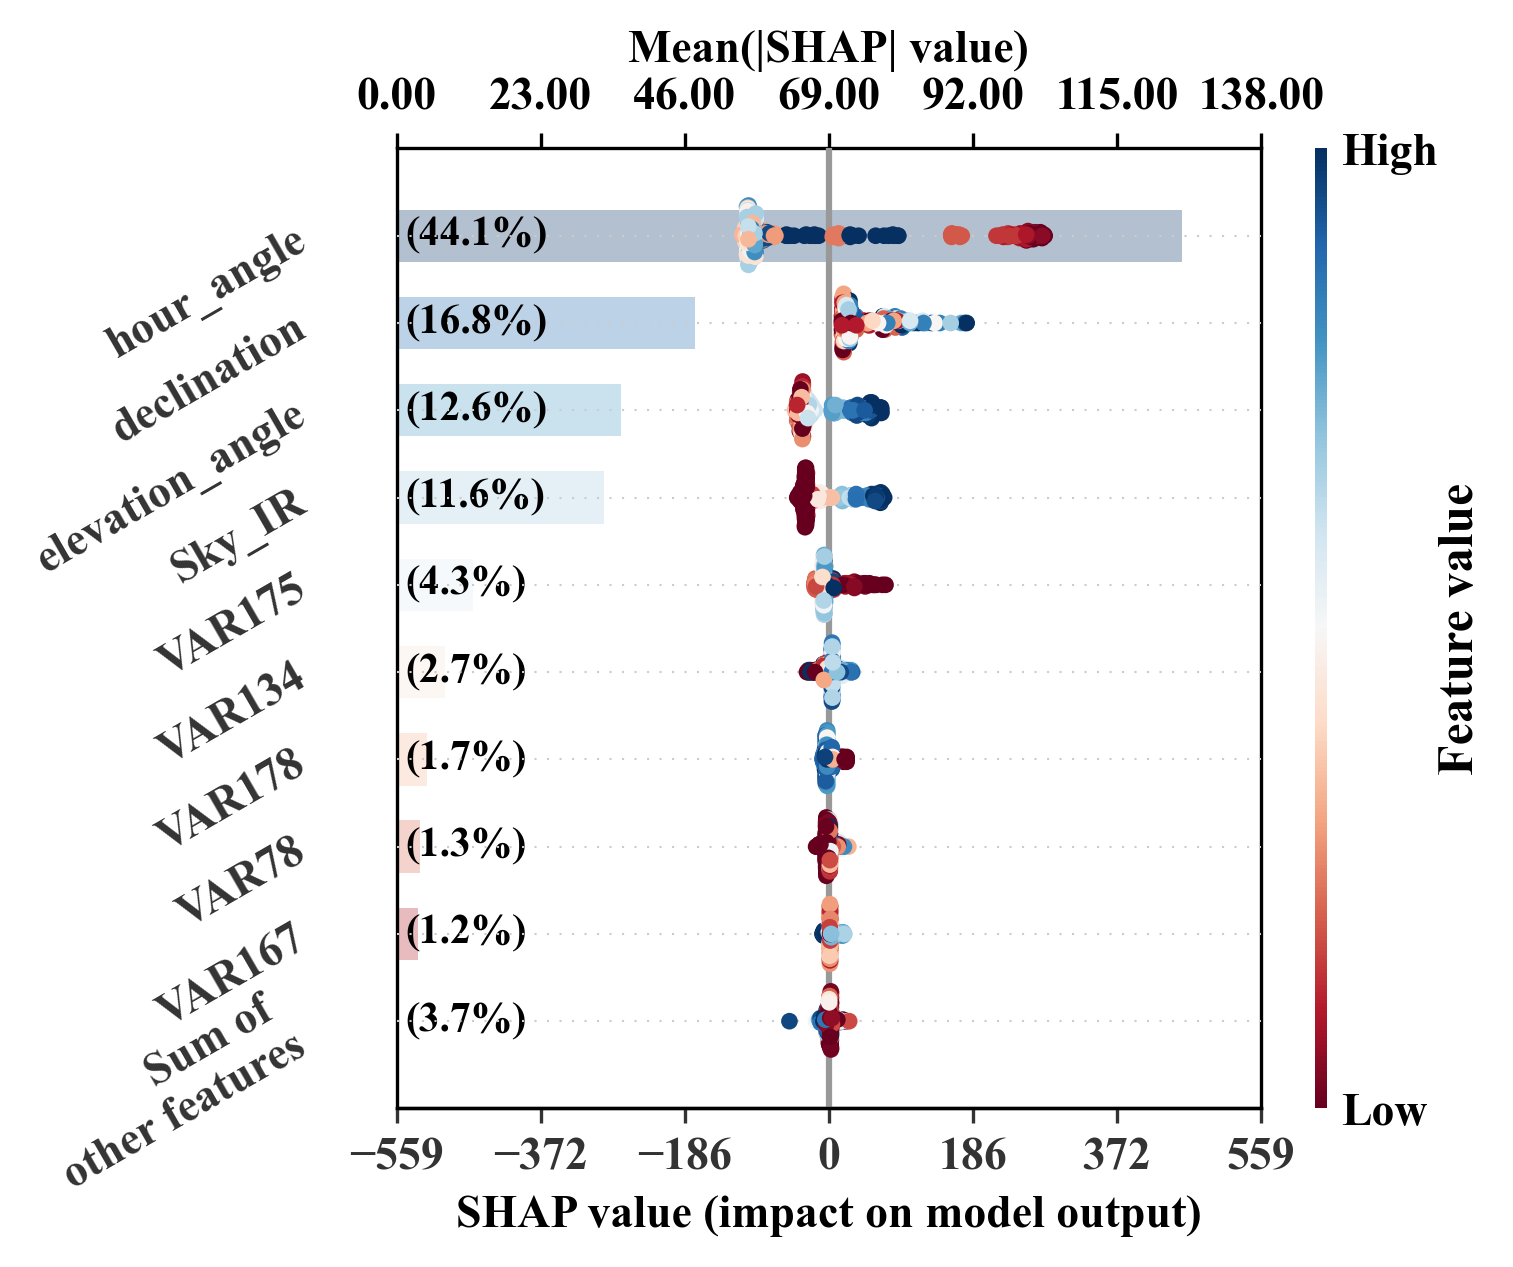

In [4]:
shap_vlues_pfn_df=pd.DataFrame(shap_vlues_pfn.values)
# shap_vlues_pfn_df.to_excel('FBS01_mean_shap_analyze.xlsx')
df_train_list1

shap_values=shap_vlues_pfn

mean_shap_value=abs(shap_values.values)

mean_shap_value1=mean_shap_value.mean(0)

features = X_train_nor_df.columns
shap_summary = pd.DataFrame({
    "Feature": features,
    "MeanSHAP": mean_shap_value1
}).sort_values("MeanSHAP", ascending=False)

sorted_feats = shap_summary["Feature"].values
feat_idx = [list(features).index(f) for f in sorted_feats]

X_test_sorted1 = X_test_nor_df_plot[sorted_feats]
X_test_sorted=X_test_sorted1.iloc[0:96*3,:]

shap_vals = shap_values.values if hasattr(shap_values, "values") else np.asarray(shap_values)
shap_vals_sorted = shap_vals[:, feat_idx]


mean_shap = shap_summary["MeanSHAP"].values
mean_shap_pct = mean_shap / mean_shap.sum() * 100


fig = plt.figure(figsize=(4.5, 4), dpi=300)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'         
plt.rcParams['axes.labelweight'] = 'bold'      
plt.rcParams['axes.titleweight'] = 'bold'     
plt.rcParams['figure.titleweight'] = 'bold'   
# plt.rcParams['legend.fontweight'] = 'bold'    
# plt.rcParams['font.size'] = 12  # 
ax_bee = fig.add_axes([0.1, 0.1, 0.8, 0.8])  # beeswarm 

   #配色   viridis  Spectral   coolwarm  RdYlGn  RdYlBu  RdBu  RdGy  PuOr  BrBG PRGn  PiYG 
cmap_name="RdBu"
cmap = cm.get_cmap(cmap_name)   

shap.plots._utils.colors.red_blue = cmap_name
cmap1 = plt.get_cmap(cmap_name)


explainer_data = shap.Explanation(
    values=shap_vals_sorted,
    data=X_test_sorted.values,
    feature_names=sorted_feats
)


shap.plots.beeswarm(explainer_data, ax=ax_bee, show=False, plot_size=None)

y_coords = ax_bee.get_yticks()
y_labels = [tick.get_text() for tick in ax_bee.get_yticklabels()]


y_order = y_labels if any(lbl != "" for lbl in y_labels) else sorted_feats


shap_mean_map = dict(zip(sorted_feats, mean_shap))
shap_pct_map = dict(zip(sorted_feats, mean_shap_pct))
bar_widths = [shap_mean_map.get(lbl, 0) for lbl in y_order]
bar_pcts1 = [shap_pct_map.get(lbl, 0) for lbl in y_order]
bar_pcts=bar_pcts1.copy()
bar_pcts[0]=100-np.sum(bar_pcts[1:])

ax_bar = ax_bee.twiny()
ax_bar.set_zorder(0)
ax_bee.set_zorder(1)
ax_bee.patch.set_alpha(0)  
colors = cmap1(np.linspace(0, 1, len(y_coords))) 
ax_bar.barh(
    y=y_coords,
    width=bar_widths,
    height=0.6,
    alpha=0.3,
    color=colors,
    edgecolor="none",
    zorder=0
)

bar_xlim = max(bar_widths) * 1.1 if max(bar_widths) > 0 else 1.0
ax_bar.set_xlim(0, bar_xlim)
ax_bar.set_xticks(np.linspace(0, bar_xlim, 7))
ax_bar.set_xticklabels([f"{x:.2f}" for x in np.linspace(0, bar_xlim, 7)], fontsize=11)
ax_bar.set_xlabel("Mean(|SHAP| value)", fontsize=11)
ax_bar.set_yticks([])


shap_xlim = round(abs(shap_vals_sorted).max() * 2, 1)
ax_bee.set_xlim(-shap_xlim, shap_xlim)
ax_bee.set_xticks(np.linspace(-shap_xlim, shap_xlim, 7))
ax_bee.set_xlabel("SHAP value (impact on model output)", fontsize=11)


ax_bee.set_yticks(y_coords)

y_order1=y_order.copy()
y_order1[0]='Sum of \nother features'
ax_bee.set_yticklabels(y_order1, fontsize=11,rotation=30)
ax_bee.tick_params(axis='y', pad=0)  

ax_bar.set_ylim(ax_bee.get_ylim())
ax_bar.tick_params(axis='y', pad=0)  

for y, p in zip(y_coords, bar_pcts):
    ax_bar.text(0.01 * bar_xlim, y, f"({p:.1f}%)", va="center", ha="left", fontsize=10, color="black")


plt.tight_layout()


plt.savefig(station_name+'_UPF3A_mean_data_shap.png', 
            dpi=600, 
            bbox_inches='tight',
            pad_inches=0.05, 
            facecolor='white')
# plt.savefig('LightGBM_mean_data_shap.png', dpi=300) 

plt.show()